# Case Study: Layerwise vs Subset Selection Analysis

This notebook generates the case study figures showing:
1. **Score magnitude** by layer type × transformer block
2. **Rank correlation with Subset** by layer type × transformer block

Data comes from the case study trainer (`analyze_selection.py`), which runs standard training while simultaneously computing Layerwise and Subset scores at each step.

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import spearmanr

# Match SFT/result.ipynb style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# Layer type definitions
LAYER_TYPES = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
TYPE_LABELS = {'q_proj': 'Q', 'k_proj': 'K', 'v_proj': 'V', 'o_proj': 'O',
               'gate_proj': 'Gate', 'up_proj': 'Up', 'down_proj': 'Down'}
type_colors = {
    'q_proj': '#E41A1C', 'k_proj': '#FF7F00', 'v_proj': '#FFD700',
    'o_proj': '#984EA3', 'gate_proj': '#377EB8', 'up_proj': '#4DAF4A',
    'down_proj': '#A65628',
}
attn_markers = {'q_proj': 'o', 'k_proj': 's', 'v_proj': '^', 'o_proj': 'v'}
mlp_markers = {'gate_proj': 'D', 'up_proj': 'P', 'down_proj': '*'}
all_markers = {**attn_markers, **mlp_markers}

save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

In [3]:
def classify_layers(layer_names):
    info = {}
    for i, name in enumerate(layer_names):
        block = -1
        parts = name.split('.')
        for j, p in enumerate(parts):
            if p == 'layers' and j + 1 < len(parts):
                block = int(parts[j + 1])
                break
        ltype = 'lm_head' if name == 'lm_head' else 'unknown'
        for t in LAYER_TYPES:
            if t in name:
                ltype = t
                break
        info[i] = {'block': block, 'type': ltype}
    return info


def load_data(path):
    with open(path) as f:
        data = json.load(f)
    layer_info = classify_layers(data['metadata']['layer_names'])
    batch_size = data['metadata']['train_batch_size']
    num_blocks = max(li['block'] for li in layer_info.values() if li['block'] >= 0) + 1

    block_type_abs = {b: {t: [] for t in LAYER_TYPES} for b in range(num_blocks)}
    block_type_spearman = {b: {t: [] for t in LAYER_TYPES} for b in range(num_blocks)}

    for sd in data['steps']:
        subset_scores = np.array(sd['subset']['selection']['scores'])
        for layer in sd['layerwise']['layers']:
            li = layer['layer_idx']
            scores = layer.get('scores', [])
            if not scores or len(scores) != batch_size:
                continue
            s = np.array(scores)
            info = layer_info[li]
            if info['type'] not in LAYER_TYPES or info['block'] < 0:
                continue
            block_type_abs[info['block']][info['type']].append(np.mean(np.abs(s)))
            rho, _ = spearmanr(s, subset_scores)
            block_type_spearman[info['block']][info['type']].append(rho)

    return {
        'block_type_abs': block_type_abs,
        'block_type_spearman': block_type_spearman,
        'num_blocks': num_blocks,
        'n_steps': len(data['steps']),
        'batch_size': batch_size,
    }


def style_ax(ax):
    ax.grid(True, alpha=0.3, linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)

## Load data

Selection records from case study runs matching the main SFT experiment configs.

In [4]:
SCRATCH = '/scratch/pbb/Project/Dr.Post-Training/SFT'

records = {
    'tulu3': f'{SCRATCH}/case_study_tulu3_tydiqa-Llama-3.2-1B-p0.01-lr4.96e-05-b8-v16-s42/selection_records.json',
    'alpaca': f'{SCRATCH}/case_study_alpaca_samsum-Llama-3.2-1B-p0.4-lr1e-06-b8-v16-s42/selection_records.json',
}

data = {}
for key, path in records.items():
    print(f'Loading {key}...')
    data[key] = load_data(path)
    print(f'  {data[key]["n_steps"]} steps, batch={data[key]["batch_size"]}, {data[key]["num_blocks"]} blocks')

Loading tulu3...
  1175 steps, batch=8, 16 blocks
Loading alpaca...
  1300 steps, batch=8, 16 blocks


## Figures: Score magnitude and rank correlation

For each dataset, we generate two plots to be placed side by side:
- **Magnitude**: Mean |influence score| by block × type
- **Correlation**: Spearman ρ with Subset by block × type

No legends on individual plots — legend is saved separately.

Saved: ./figures/magnitude_tulu3.pdf


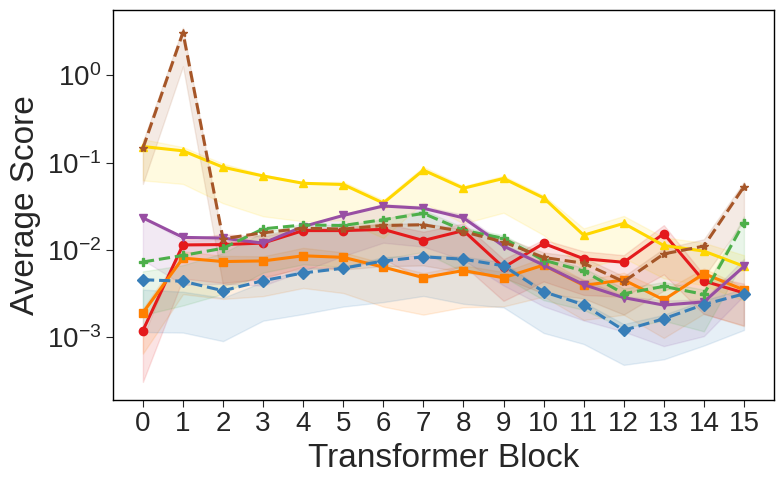

Saved: ./figures/correlation_tulu3.pdf


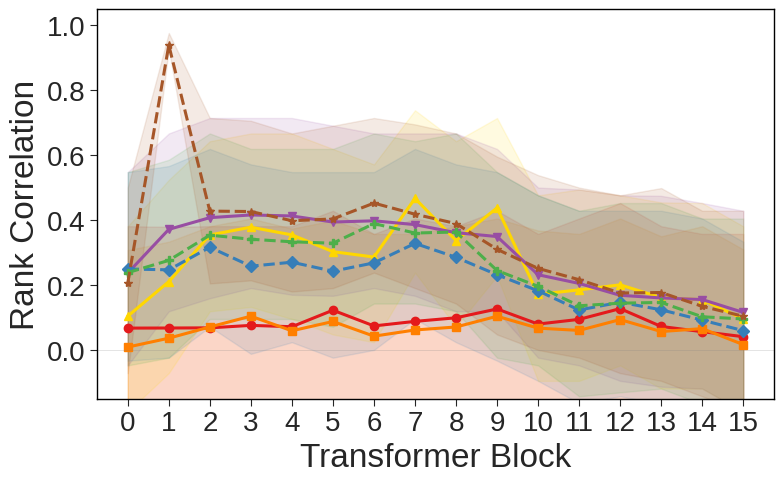

Saved: ./figures/magnitude_alpaca.pdf


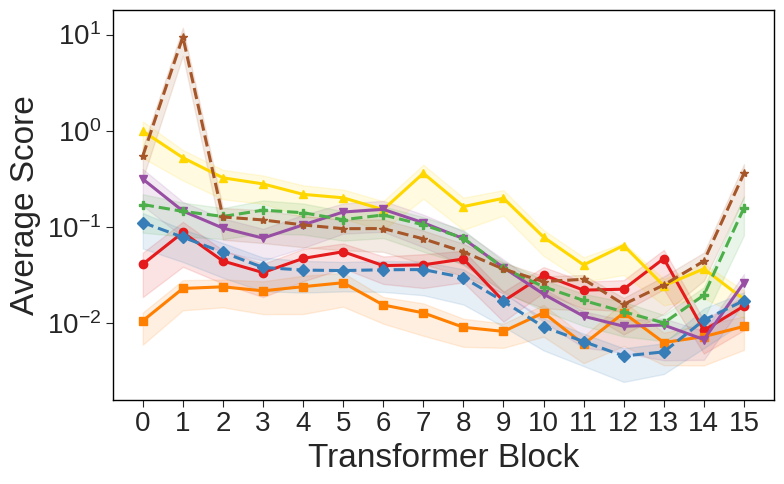

Saved: ./figures/correlation_alpaca.pdf


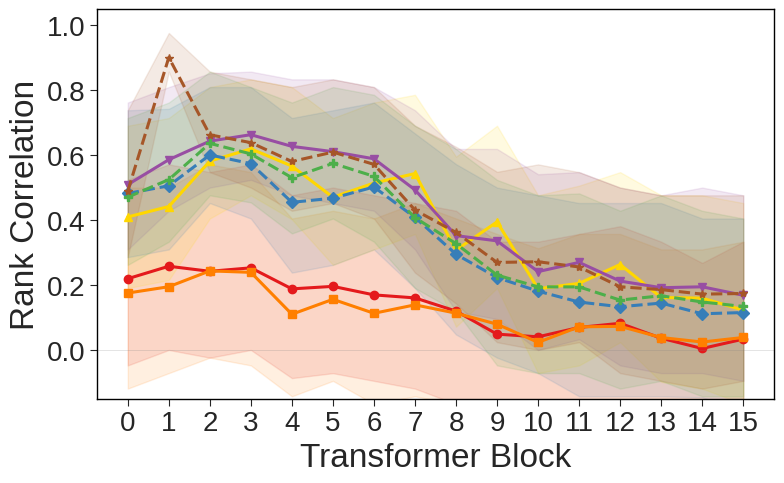

In [5]:
for key, res in data.items():
    blocks = list(range(res['num_blocks']))

    # ── Magnitude ──
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    for t in LAYER_TYPES:
        means, lo, hi = [], [], []
        for b in blocks:
            vals = res['block_type_abs'][b][t]
            if vals:
                means.append(np.mean(vals))
                lo.append(np.percentile(vals, 25))
                hi.append(np.percentile(vals, 75))
            else:
                means.append(0); lo.append(0); hi.append(0)
        ls = '-' if t in attn_markers else '--'
        ax.plot(blocks, means, color=type_colors[t], linewidth=2.2,
                marker=all_markers[t], markersize=6, linestyle=ls)
        ax.fill_between(blocks, lo, hi, color=type_colors[t], alpha=0.12)

    ax.set_xlabel('Transformer Block', fontsize=24)
    ax.set_ylabel('Average Score', fontsize=24)
    ax.set_yscale('log')
    ax.set_xticks(blocks)
    style_ax(ax)

    plt.tight_layout()
    filepath = os.path.join(save_dir, f'magnitude_{key}.pdf')
    fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
    print(f'Saved: {filepath}')
    plt.show()

    # ── Correlation ──
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    for t in LAYER_TYPES:
        means, lo, hi = [], [], []
        for b in blocks:
            vals = res['block_type_spearman'][b][t]
            if vals:
                means.append(np.mean(vals))
                lo.append(np.percentile(vals, 25))
                hi.append(np.percentile(vals, 75))
            else:
                means.append(0); lo.append(0); hi.append(0)
        ls = '-' if t in attn_markers else '--'
        ax.plot(blocks, means, color=type_colors[t], linewidth=2.2,
                marker=all_markers[t], markersize=6, linestyle=ls)
        ax.fill_between(blocks, lo, hi, color=type_colors[t], alpha=0.12)

    ax.set_xlabel('Transformer Block', fontsize=24)
    ax.set_ylabel('Rank Correlation', fontsize=24)
    ax.set_xticks(blocks)
    ax.set_ylim(-0.15, 1.05)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3)
    style_ax(ax)

    plt.tight_layout()
    filepath = os.path.join(save_dir, f'correlation_{key}.pdf')
    fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
    print(f'Saved: {filepath}')
    plt.show()

## Standalone legend

Saved legend: ./figures/legend.pdf


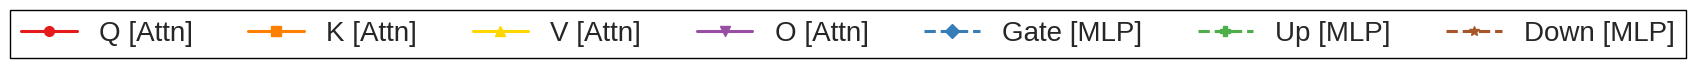

In [6]:
fig_leg, ax_leg = plt.subplots(figsize=(10, 0.6))
ax_leg.set_axis_off()
fig_leg.patch.set_facecolor('white')

handles = []
labels = []
for t in LAYER_TYPES:
    ls = '-' if t in attn_markers else '--'
    h = plt.Line2D([0], [0], color=type_colors[t], linewidth=2.2,
                    marker=all_markers[t], markersize=7, linestyle=ls)
    group = '[Attn]' if t in attn_markers else '[MLP]'
    handles.append(h)
    labels.append(f'{TYPE_LABELS[t]} {group}')

legend = fig_leg.legend(handles, labels, loc='center', ncol=len(LAYER_TYPES),
                        fontsize=20, frameon=True, edgecolor='black',
                        fancybox=False, framealpha=1.0, facecolor='white')
legend.get_frame().set_linewidth(1.0)

filepath = os.path.join(save_dir, 'legend.pdf')
fig_leg.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f'Saved legend: {filepath}')
plt.show()

## Summary statistics

In [7]:
for key, res in data.items():
    print(f'\n{"=" * 60}')
    print(f'  {key} ({res["n_steps"]} steps, batch={res["batch_size"]})')
    print(f'{"=" * 60}')

    # Type-averaged magnitude
    print(f'\n  Score magnitude (mean |score| across all blocks):')
    type_means = {}
    for t in LAYER_TYPES:
        all_vals = []
        for b in range(res['num_blocks']):
            all_vals.extend(res['block_type_abs'][b][t])
        type_means[t] = np.mean(all_vals) if all_vals else 0
    down_mean = type_means['down_proj']
    for t in LAYER_TYPES:
        ratio = down_mean / type_means[t] if type_means[t] > 0 else 0
        print(f'    {TYPE_LABELS[t]:<6s}: {type_means[t]:.6f}  (Down is {ratio:.0f}x larger)')

    # Type-averaged Spearman with Subset
    print(f'\n  Spearman with Subset (mean across all blocks):')
    for t in LAYER_TYPES:
        all_vals = []
        for b in range(res['num_blocks']):
            all_vals.extend(res['block_type_spearman'][b][t])
        m = np.mean(all_vals) if all_vals else 0
        print(f'    {TYPE_LABELS[t]:<6s}: {m:.4f}')


  tulu3 (1175 steps, batch=8)

  Score magnitude (mean |score| across all blocks):
    Q     : 0.010750  (Down is 20x larger)
    K     : 0.005613  (Down is 39x larger)
    V     : 0.056117  (Down is 4x larger)
    O     : 0.014183  (Down is 15x larger)
    Gate  : 0.004526  (Down is 48x larger)
    Up    : 0.012780  (Down is 17x larger)
    Down  : 0.217273  (Down is 1x larger)

  Spearman with Subset (mean across all blocks):
    Q     : 0.0831
    K     : 0.0628
    V     : 0.2624
    O     : 0.2980
    Gate  : 0.2139
    Up    : 0.2529
    Down  : 0.3392

  alpaca (1300 steps, batch=8)

  Score magnitude (mean |score| across all blocks):
    Q     : 0.037656  (Down is 19x larger)
    K     : 0.014431  (Down is 49x larger)
    V     : 0.230507  (Down is 3x larger)
    O     : 0.084357  (Down is 8x larger)
    Gate  : 0.032967  (Down is 21x larger)
    Up    : 0.090916  (Down is 8x larger)
    Down  : 0.701127  (Down is 1x larger)

  Spearman with Subset (mean across all blocks):
  